Dataset extracted successfully!
['.config', 'Plant_Disease_Workshop', '1000003322.jpg', 'Plant_Disease_Workshop.zip', 'sample_data']
['val', 'train']
['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
========= Train Data=======
Potato___Early_blight : 800
Potato___Early_blight : 800 image
Potato___Late_blight : 800
Potato___Late_blight : 800 image
Potato___healthy : 121
Potato___healthy : 121 image
========= Val Data=======
Potato___Early_blight : 200
Potato___Early_blight : 200 image
Potato___Late_blight : 200
Potato___Late_blight : 200 image
Potato___healthy : 31
Potato___healthy : 31 image


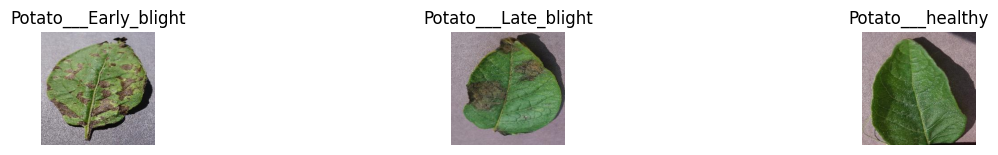

Train Images loaded Successfully
Val Images loaded Successfully
Training Images: 1721
Training Labels: 1721
========== ======================
Validation Images: 431
Validation Labels: 431


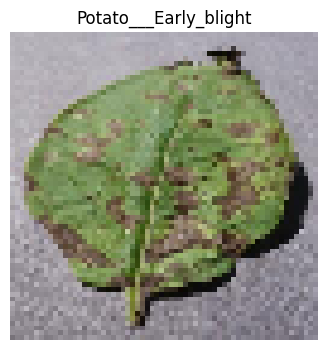

Converted Successfully
Training Shape: (1721, 64, 64, 3)
Validation Shape: (431, 64, 64, 3)
(1721, 12288)
(431, 12288)
Reshaped Successfully
Normalized Successfully
Labels Encoded Successfully
Encoded Classes: ['Potato___Early_blight' 'Potato___Late_blight' 'Potato___healthy']
[0 0 0 0 0 0 0 0 0 0]
Training features Shape: (1721, 12288)
Training labels Shape: (1721,)
Validation features Shape: (431, 12288)
Validation labels Shape: (431,)
Logistic Regression Model Created Successfully
Model Training completed
Prediction completed
Actual Labels: [0 0 0 0 0 0 0 0 0 0]
Predicted Labels: [0 0 0 0 0 0 0 0 0 0]
Accuracy Score is 90.72 %
[[185  15   0]
 [  8 189   3]
 [  0  14  17]]
                       precision    recall  f1-score   support

Potato___Early_blight       0.96      0.93      0.94       200
 Potato___Late_blight       0.87      0.94      0.90       200
     Potato___healthy       0.85      0.55      0.67        31

             accuracy                           0.91       431

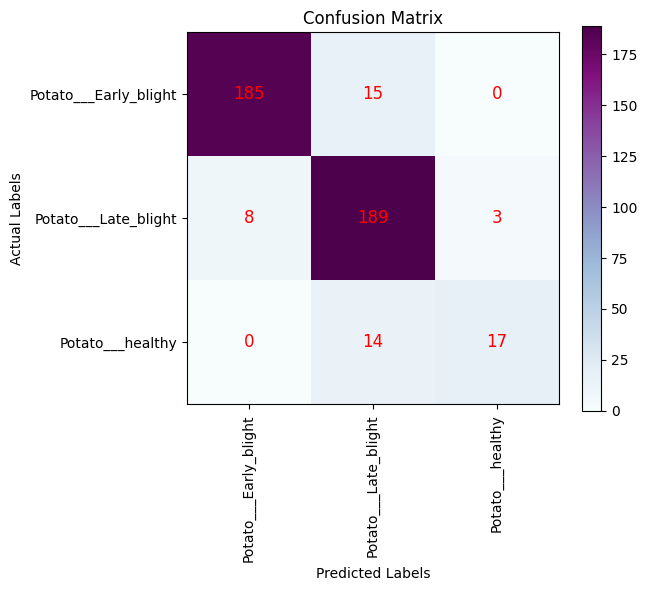

Logistic Regression Model completed Successfully
Accuracy : 90.72%
Support Vector Machine Model Created Successfully
Model Training completed
Prediction completed
Accuracy Score is 91.18 %
[[183  17   0]
 [  9 188   3]
 [  1   8  22]]


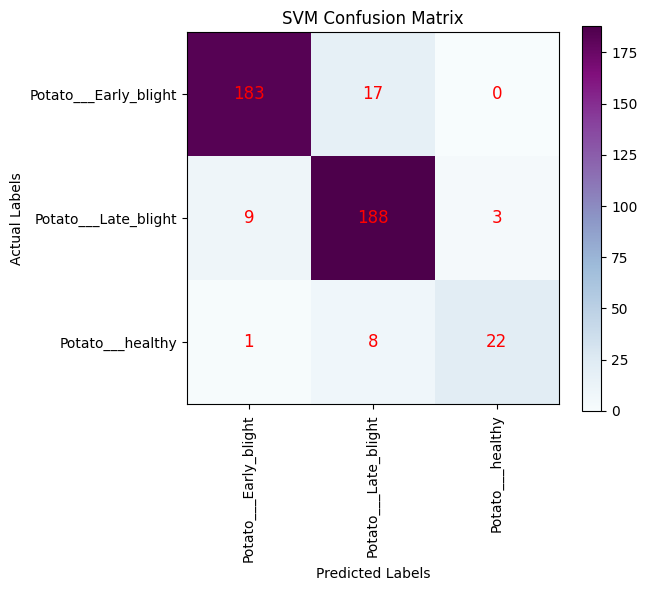

SVM Model completed Successfully
Accuracy : 91.18%


Saving leaf_image.jpg to leaf_image.jpg


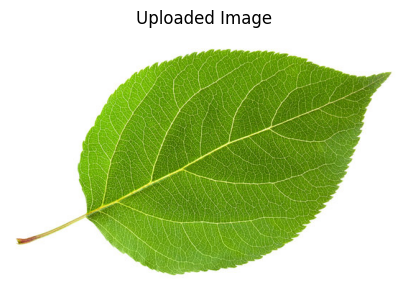

Image PreProcessed Successfully!
Predicted Disease: Potato___healthy
Disease: Healthy
Advice: No Action Required

Model Evaluation Comparison:
                    Model   Accuracy
0     Logistic Regression  90.719258
1  Support Vector Machine  91.183295


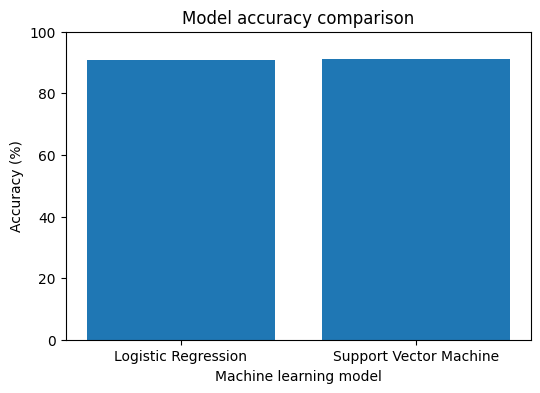

Best model : support vector machine


In [3]:
import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from google.colab import files

# ==========================================
# 1. Dataset Extraction & Directory Setup
# ==========================================
zip_path = "/content/Plant_Disease_Workshop.zip"
np.extract_path = "/content"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(np.extract_path)

print("Dataset extracted successfully!")
print(os.listdir("/content"))

dataset_path = "/content/Plant_Disease_Workshop"
print(os.listdir(dataset_path))

train_path = "/content/Plant_Disease_Workshop/train"
print(os.listdir(train_path))

val_path = "/content/Plant_Disease_Workshop/val"
print(os.listdir(val_path))

# Check train dataset distribution
print("========= Train Data=======")
for folder in os.listdir(train_path):
    folder_path = os.path.join(train_path, folder)
    print(folder, ":", len(os.listdir(folder_path)))
    print(folder, ":", len(os.listdir(folder_path)), "image")

# Check validation dataset distribution
print("========= Val Data=======")
for folder in os.listdir(val_path):
    folder_path = os.path.join(val_path, folder)
    print(folder, ":", len(os.listdir(folder_path)))
    print(folder, ":", len(os.listdir(folder_path)), "image")

# ==========================================
# 2. Visualizing Sample Training Images
# ==========================================
plt.figure(figsize=(15, 5))
classes = os.listdir(train_path)
for i, folder in enumerate(classes):
    image_name = os.listdir(os.path.join(train_path, folder))[0]
    image_path = os.path.join(train_path, folder, image_name)
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(folder)
    plt.axis("off")
plt.show()

# ==========================================
# 3. Data Loading & Preprocessing
# ==========================================
image_size = (64, 64)
X_train = []
y_train = []
X_val = []
y_val = []

# Load Training Images
for label in os.listdir(train_path):
    folder_path = os.path.join(train_path, label)
    for image_name in os.listdir(folder_path):
        image_path = os.path.join(folder_path, image_name)
        image = cv2.imread(image_path)
        image = cv2.resize(image, image_size)
        X_train.append(image)
        y_train.append(label)
print("Train Images loaded Successfully")

# Load Validation Images
for label in os.listdir(val_path):
    folder_path = os.path.join(val_path, label)
    for image_name in os.listdir(folder_path):
        image_path = os.path.join(folder_path, image_name)
        image = cv2.imread(image_path)
        image = cv2.resize(image, image_size)
        X_val.append(image)
        y_val.append(label)
print("Val Images loaded Successfully")

print("Training Images:", len(X_train))
print("Training Labels:", len(y_train))
print("========== ======================")
print("Validation Images:", len(X_val))
print("Validation Labels:", len(y_val))

# Plot a single training image example
plt.figure(figsize=(4, 4))
plt.imshow(cv2.cvtColor(X_train[0], cv2.COLOR_BGR2RGB))
plt.title(y_train[0])
plt.axis("off")
plt.show()

# Convert lists to numpy arrays
X_train = np.array(X_train)
X_val = np.array(X_val)
y_train = np.array(y_train)
y_val = np.array(y_val)
print("Converted Successfully")

print("Training Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)

# Flatten arrays for traditional machine learning models
X_train = X_train.reshape(X_train.shape[0], -1)
X_val = X_val.reshape(X_val.shape[0], -1)
print(X_train.shape)
print(X_val.shape)
print("Reshaped Successfully")

# Normalize pixel values
X_train = X_train / 255.0
X_val = X_val / 255.0
print("Normalized Successfully")

# Label Encoding
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_val = encoder.transform(y_val)  # Note: transformed instead of fit_transform for consistency
print("Labels Encoded Successfully")
print("Encoded Classes:", encoder.classes_)
print(y_train[:10])

print("Training features Shape:", X_train.shape)
print("Training labels Shape:", y_train.shape)
print("=========================")
print("Validation features Shape:", X_val.shape)
print("Validation labels Shape:", y_val.shape)

# ==========================================
# 4. Logistic Regression Model
# ==========================================
logistic_model = LogisticRegression(max_iter=1000)
print("Logistic Regression Model Created Successfully")

logistic_model.fit(X_train, y_train)
print("Model Training completed")

y_pred = logistic_model.predict(X_val)
print("Prediction completed")
print("Actual Labels:", y_val[:10])
print("Predicted Labels:", y_pred[:10])

acc = accuracy_score(y_val, y_pred)
print("Accuracy Score is", round(acc * 100, 2), "%")

cmx = confusion_matrix(y_val, y_pred)
print(cmx)

print(classification_report(y_val, y_pred, target_names=encoder.classes_))

predicted_labels = encoder.inverse_transform(y_pred[:10])
print("First 10 predicted Disease Names:")
print(predicted_labels)

# Plot Logistic Regression Confusion Matrix
plt.figure(figsize=(6, 5))
plt.imshow(cmx, cmap="BuPu")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(range(3), encoder.classes_, rotation=90)
plt.yticks(range(3), encoder.classes_)
for i in range(len(cmx)):
    for j in range(len(cmx)):
        plt.text(j, i, cmx[i][j], ha="center", va="center", color="red", fontsize=12)
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.show()

print("=" * 40)
print("Logistic Regression Model completed Successfully")
print("=" * 40)
print(f"Accuracy : {acc * 100:.2f}%")

# ==========================================
# 5. Support Vector Machine (SVM) Model
# ==========================================
svm_model = SVC(kernel="linear")
print("Support Vector Machine Model Created Successfully")

svm_model.fit(X_train, y_train)
print("Model Training completed")

y_pred_svm = svm_model.predict(X_val)
print("Prediction completed")

Acc = accuracy_score(y_val, y_pred_svm)
print("Accuracy Score is", round(Acc * 100, 2), "%")

svm_cm = confusion_matrix(y_val, y_pred_svm)
print(svm_cm)

# Plot SVM Confusion Matrix
plt.figure(figsize=(6, 5))
plt.imshow(svm_cm, cmap="BuPu")
plt.title("SVM Confusion Matrix")
plt.colorbar()
plt.xticks(range(3), encoder.classes_, rotation=90)
plt.yticks(range(3), encoder.classes_)
for i in range(len(svm_cm)):
    for j in range(len(svm_cm)):
        plt.text(j, i, svm_cm[i][j], ha="center", va="center", color="red", fontsize=12)
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.show()

print("=" * 40)
print("SVM Model completed Successfully")
print("=" * 40)
print(f"Accuracy : {Acc * 100:.2f}%")

# ==========================================
# 6. Prediction on Custom Uploaded Image
# ==========================================
uploaded = files.upload()
image_name = list(uploaded.keys()) [0]
image = cv2.imread(image_name)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(image_rgb)
plt.title("Uploaded Image")
plt.axis("off")
plt.show()

# Process custom image
test_image = cv2.resize(image, (64, 64))
test_image = test_image.reshape(1, -1)
test_image = test_image / 255.0
print("Image PreProcessed Successfully!")

# Predict using the trained SVM model
prediction = svm_model.predict(test_image)
predicted_disease = encoder.inverse_transform(prediction)
print("Predicted Disease:", predicted_disease[0])

# Treatment / Action Logic
if predicted_disease[0] == "Potato___Early_blight":
    print("Disease: Early Blight")
    print("Advice: Remove infected leaves and apply fungicide")
elif predicted_disease[0] == "Potato___Late_blight":
    print("Disease: Late Blight")
    print("Advice: Remove infected leaves and apply fungicide")
else:
    print("Disease: Healthy")
    print("Advice: No Action Required")

# ==========================================
# 7. Model Comparison
# ==========================================
comparison = {
    "Model": ["Logistic Regression", "Support Vector Machine"],
    "Accuracy": [acc * 100, Acc * 100]
}

comparison_df = pd.DataFrame(comparison)
print("\nModel Evaluation Comparison:")
print(comparison_df)

plt.figure(figsize=(6,4))
plt.bar(comparison_df["Model"], comparison_df["Accuracy"])
plt.title("Model accuracy comparison")
plt.xlabel("Machine learning model")
plt.ylabel("Accuracy (%)")
plt.ylim(0,100)
plt.show()

if Acc > acc:
  print("Best model : support vector machine")
else:
  print("Best model : logistic regression")